## 1 - Project Setup
This section initializes the workspace, mounts Google Drive, extracts the dataset, and authenticates with HuggingFace Hub.

**Note:** DINOv3 checkpoints on HuggingFace are gated. You need to accept the license at
https://huggingface.co/facebook/dinov3-convnext-small-pretrain-lvd1689m and have an access
token with read permission before running the login cell below.

In [1]:
%pip install -q transformers huggingface_hub accelerate

import os
import glob
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import torch
import torch.nn as nn
import torch.optim as optim
from huggingface_hub import login
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from transformers import AutoModel
from tqdm.auto import tqdm
import random
import gc

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Environment setup: works both on Colab (Drive-mounted) and on a local VM/JupyterLab.
try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    DRIVE_ROOT = '/content/drive/MyDrive/internship-deepfake-forensic'
    DATASET_DIR = '/content/dataset'
    MODELS_DIR = os.path.join(DRIVE_ROOT, 'deepfake_models_final')

    if not os.path.exists(DATASET_DIR):
        print("Extracting the dataset... (this might take a few minutes)")
        !unzip -q {os.path.join(DRIVE_ROOT, 'deepfake_dataset.zip')} -d {DATASET_DIR}
        print("Extraction completed!")
    else:
        print("Dataset already present and ready to use!")
else:
    DATA_ROOT = '/home/lucia_pola/internship-deepfake-forensic/deepfake-forensics-pipeline/02_Extended_Framework'
    DATASET_DIR = os.path.join(DATA_ROOT, 'Datasets')
    MODELS_DIR = os.path.join(DATA_ROOT, 'deepfake_models_final')
    print(f"Running outside Colab. Using local paths under: {DATA_ROOT}")

os.makedirs(MODELS_DIR, exist_ok=True)
print(f"Dataset directory: {DATASET_DIR}")
print(f"Models directory:  {MODELS_DIR}")

Running outside Colab. Using local paths under: /home/lucia_pola/internship-deepfake-forensic/deepfake-forensics-pipeline/02_Extended_Framework
Dataset directory: /home/lucia_pola/internship-deepfake-forensic/deepfake-forensics-pipeline/02_Extended_Framework/Datasets
Models directory:  /home/lucia_pola/internship-deepfake-forensic/deepfake-forensics-pipeline/02_Extended_Framework/deepfake_models_final


In [3]:
# Log in to HuggingFace Hub to access the gated DINOv3 checkpoints
login()

## 2 - Dataset and Advanced Augmentation

In [4]:
class DeepfakeDataset(Dataset):
    def __init__(self, real_dirs, fake_dirs, transform=None):
        self.filepaths, self.labels = [], []
        self.transform = transform
        extensions = ('*.png', '*.jpg', '*.jpeg', '*.PNG', '*.JPG', '*.JPEG')
        for d in real_dirs:
            for ext in extensions:
                paths = sorted(glob.glob(os.path.join(d, ext)))
                self.filepaths.extend(paths)
                self.labels.extend([0] * len(paths))
        for d in fake_dirs:
            for ext in extensions:
                paths = sorted(glob.glob(os.path.join(d, ext)))
                self.filepaths.extend(paths)
                self.labels.extend([1] * len(paths))

    def __len__(self):
        return len(self.filepaths)

    def __getitem__(self, idx):
        img = Image.open(self.filepaths[idx]).convert('RGB')
        if self.transform:
            img = self.transform(img)
        label = torch.tensor([self.labels[idx]], dtype=torch.float32)
        return img, label

class MultipleJpegCompression:
    """
    Applies multiple sequential JPEG compressions (Ideal for the Advanced pipeline).
    Simulates scenarios where an image is uploaded, downloaded, and reshared multiple times.
    """
    def __init__(self, min_quality=50, max_quality=90, min_passes=2, max_passes=4, p=0.5):
        self.min_quality = min_quality
        self.max_quality = max_quality
        self.min_passes = min_passes
        self.max_passes = max_passes
        self.p = p

    def __call__(self, img):
        if torch.rand(1).item() > self.p:
            return img

        # Chooses how many consecutive times to compress the image
        num_passes = torch.randint(self.min_passes, self.max_passes + 1, (1,)).item()

        for _ in range(num_passes):
            quality = torch.randint(self.min_quality, self.max_quality + 1, (1,)).item()
            buffer = io.BytesIO()
            img.save(buffer, format="JPEG", quality=quality)
            buffer.seek(0)
            img = Image.open(buffer).convert("RGB")

        return img

# ADVANCED AUGMENTATION
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)), # Fail-safe resize
    MultipleJpegCompression(min_quality=60, max_quality=95, p=0.5),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomAffine(degrees=15, translate=(0.1, 0.1), scale=(0.9, 1.1), shear=10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.5, scale=(0.02, 0.15), ratio=(0.3, 3.3), value=0)
])

val_test_transforms = transforms.Compose([
    transforms.Resize((224, 224)), # Fail-safe resize
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
])

## 3 - Model Architecture (DINOv3 ConvNeXt-Small, frozen backbone)

In [5]:
class DINOv3ConvNeXtClassifier(nn.Module):
    """
    DINOv3 ConvNeXt-Small as a frozen Foundation-CNN feature extractor, with only a
    lightweight classification head trained on top. Following DBCF, LGSFNet and
    SemDINO, the DINOv3 backbone is kept fully frozen: fine-tuning it (even partially)
    tends to erode the pretrained representation on a small downstream dataset.
    """
    def __init__(self, num_classes=1, model_id="facebook/dinov3-convnext-small-pretrain-lvd1689m"):
        super().__init__()
        self.backbone = AutoModel.from_pretrained(model_id)
        for p in self.backbone.parameters():
            p.requires_grad = False

        hidden_sizes = getattr(self.backbone.config, "hidden_sizes", None)
        hidden_size = hidden_sizes[-1] if hidden_sizes is not None else self.backbone.config.hidden_size

        self.classifier = nn.Sequential(
            nn.Dropout(p=0.4),
            nn.Linear(hidden_size, num_classes)
        )

    def train(self, mode=True):
        # Keep the frozen backbone in eval mode even when the wrapper is set to train()
        super().train(mode)
        self.backbone.eval()
        return self

    def state_dict(self, *args, **kwargs):
        # Only the classification head is trainable: skip the large frozen backbone
        # so checkpoints stay small and fast to write to Drive.
        return self.classifier.state_dict(*args, **kwargs)

    def load_state_dict(self, state_dict, *args, **kwargs):
        return self.classifier.load_state_dict(state_dict, *args, **kwargs)

    def forward(self, x):
        with torch.no_grad():
            outputs = self.backbone(pixel_values=x)
            features = getattr(outputs, "pooler_output", None)
            if features is None:
                last_hidden = outputs.last_hidden_state
                # [B, C, H, W] conv feature map vs [B, N, C] token sequence
                features = last_hidden.mean(dim=[-2, -1]) if last_hidden.dim() == 4 else last_hidden.mean(dim=1)
        return self.classifier(features)

## 4 - Training Engine

In [6]:
class EarlyStopping:
    def __init__(self, patience=10, delta=0.001, path='best_model.pth'):
        self.patience, self.delta, self.path = patience, delta, path
        self.counter, self.best_score, self.early_stop = 0, None, False
        self.val_loss_min = np.inf

    def __call__(self, val_loss, model):
        score = -val_loss
        if self.best_score is None:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
        elif score < self.best_score + self.delta:
            self.counter += 1
            if self.counter >= self.patience: self.early_stop = True
        else:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
            self.counter = 0

    #ModelCheckPoint - save the model when improve
    def save_checkpoint(self, val_loss, model):
        torch.save(model.state_dict(), self.path)
        self.val_loss_min = val_loss

def train_and_validate(model, train_loader, val_loader, epochs, optimizer, criterion, device, early_stopper, scheduler=None):
    scaler = torch.amp.GradScaler('cuda')

    history = {
        'epoch': [],
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': []
    }

    for epoch in range(epochs):
        # TRAINING PHASE
        model.train()
        train_loss, train_correct, train_total = 0.0, 0, 0

        train_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]", unit="batch", leave=False)

        for images, labels in train_bar:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()

            with torch.amp.autocast('cuda'):
                outputs = model(images)
                loss = criterion(outputs, labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            train_loss += loss.item() * images.size(0)

            predicted = (outputs > 0.0).float()
            train_total += labels.size(0)
            train_correct += (predicted == labels).sum().item()
            train_bar.set_postfix(loss=loss.item(), acc=train_correct/train_total)

        # VALIDATION PHASE
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        val_bar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} [Val]", unit="batch", leave=False)

        with torch.no_grad():
            for images, labels in val_bar:
                images, labels = images.to(device), labels.to(device)

                with torch.amp.autocast('cuda'):
                    outputs = model(images)
                    loss = criterion(outputs, labels)

                val_loss += loss.item() * images.size(0)

                predicted = (outputs > 0.0).float()
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        avg_train_loss = train_loss / train_total
        avg_val_loss = val_loss / val_total
        train_acc = train_correct / train_total
        val_acc = val_correct / val_total

        print(f"END EPOCH {epoch+1} -> Train Loss: {avg_train_loss:.4f}, Acc: {train_acc:.4f} | Val Loss: {avg_val_loss:.4f}, Acc: {val_acc:.4f}")

        history['epoch'].append(epoch + 1)
        history['train_loss'].append(avg_train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(avg_val_loss)
        history['val_acc'].append(val_acc)

        # SCHEDULER LOGIC
        if scheduler is not None:
            if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step(avg_val_loss)
            else:
                scheduler.step()

        early_stopper(avg_val_loss, model)
        if early_stopper.early_stop:
            print(">> Early stopping activate!")
            break
        print("-" * 30)

    history_path = early_stopper.path.replace('.pth', '_history.csv')
    pd.DataFrame(history).to_csv(history_path, index=False)
    print(f"Training history saved successfully in: {history_path}")

    return history

def load_or_train(model, model_path, train_loader, val_loader, epochs, optimizer, criterion, device, early_stopper, scheduler=None):
    history = None
    if os.path.exists(model_path):
        print(f"Model found! Skipping training and loading weights from:\n{model_path}")
        model.load_state_dict(torch.load(model_path, map_location=device))

        history_path = model_path.replace('.pth', '_history.csv')
        if os.path.exists(history_path):
            history = pd.read_csv(history_path).to_dict(orient='list')
            print(f"Training history loaded from: {history_path}")
    else:
        print(f"Model not found. Starting the training procedure...")
        history = train_and_validate(
            model, train_loader, val_loader, epochs, optimizer,
            criterion, device, early_stopper, scheduler
        )
        # Load the best model saved by EarlyStopping at the end of training
        model.load_state_dict(torch.load(model_path, map_location=device))

    return history

## 5 - Data Configuration

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device in use: {device}")

path_intra = os.path.join(MODELS_DIR, 'retrain_dino', 'path')
os.makedirs(path_intra, exist_ok=True)
print(f"In this second step the model is saved in: {path_intra}")

BATCH_SIZE = 32
MAX_EPOCHS = 15
PATIENCE = 10
NUM_WORKERS = 4

# SETUP
tr_reals = [f'{DATASET_DIR}/FEI_MORPHV2_DATASET/train/original/', f'{DATASET_DIR}/CELEBDFV3_DATASET/train/original/']
tr_fakes = [f'{DATASET_DIR}/FEI_MORPHV2_DATASET/train/fake/', f'{DATASET_DIR}/CELEBDFV3_DATASET/train/fake/']
vl_reals = [f'{DATASET_DIR}/FEI_MORPHV2_DATASET/val/original/', f'{DATASET_DIR}/CELEBDFV3_DATASET/val/original/']
vl_fakes = [f'{DATASET_DIR}/FEI_MORPHV2_DATASET/val/fake/', f'{DATASET_DIR}/CELEBDFV3_DATASET/val/fake/']

train_ds = DeepfakeDataset(tr_reals, tr_fakes, train_transforms)
val_ds = DeepfakeDataset(vl_reals, vl_fakes, val_test_transforms)

def get_criterion_from_labels(labels):
    num_reals = labels.count(0)
    num_fakes = labels.count(1)
    balance_ratio = num_reals / num_fakes if num_fakes > 0 else 1.0
    print(f"Class balance computed: {num_reals} Real / {num_fakes} Fake (pos_weight: {balance_ratio:.4f})")
    return nn.BCEWithLogitsLoss(pos_weight=torch.tensor([balance_ratio]).to(device))

print("\nComputing class weights:")
criterion = get_criterion_from_labels(train_ds.labels)

# DataLoaders
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True, num_workers=NUM_WORKERS, persistent_workers=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, pin_memory=True, num_workers=NUM_WORKERS, persistent_workers=True)

Device in use: cuda
In this second step the model is saved in: /home/lucia_pola/internship-deepfake-forensic/deepfake-forensics-pipeline/02_Extended_Framework/deepfake_models_final/retrain_dino/path

Computing class weights:
Class balance computed: 2435 Real / 155339 Fake (pos_weight: 0.0157)


## 6 - Training

In [8]:
path_baseline = os.path.join(MODELS_DIR, 'baseline_dino', 'path')

print("\n--- DINOV3 CONVNEXT-SMALL --> START TRAINING ---")

model_dino_convnext = DINOv3ConvNeXtClassifier().to(device)

# LOAD BASELINE WEIGHTS (If they exist)
baseline_dino_path = os.path.join(path_baseline, "dino_convnext_small_step1.pth")
if os.path.exists(baseline_dino_path):
    print(f"Loading Baseline weights from: {baseline_dino_path}")
    model_dino_convnext.load_state_dict(torch.load(baseline_dino_path, map_location=device))
else:
    print("WARNING: Baseline file not found! Training will start from scratch.")

# Only the classification head is trainable (backbone is frozen)
trainable_params = [p for p in model_dino_convnext.parameters() if p.requires_grad]
optimizer_dino = optim.AdamW(trainable_params, lr=1e-5, weight_decay=1e-5)
scheduler_dino = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_dino, mode='min', factor=0.5, patience=2
)
path_dino_convnext = os.path.join(path_intra, "dino_convnext_small_step2.pth")
early_stopper_dino = EarlyStopping(patience=PATIENCE, path=path_dino_convnext)

load_or_train(
    model_dino_convnext,
    path_dino_convnext,
    train_loader,
    val_loader,
    MAX_EPOCHS,
    optimizer_dino,
    criterion,
    device,
    early_stopper_dino,
    scheduler_dino
)

# Free GPU memory
del model_dino_convnext, optimizer_dino, scheduler_dino
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()


--- DINOV3 CONVNEXT-SMALL --> START TRAINING ---


Loading weights:   0%|          | 0/342 [00:00<?, ?it/s]

Loading Baseline weights from: /home/lucia_pola/internship-deepfake-forensic/deepfake-forensics-pipeline/02_Extended_Framework/deepfake_models_final/baseline_dino/path/dino_convnext_small_step1.pth
Model not found. Starting the training procedure...


Epoch 1/15 [Train]:   0%|          | 0/4931 [00:00<?, ?batch/s]

Epoch 1/15 [Val]:   0%|          | 0/322 [00:00<?, ?batch/s]

...

Epoch 10/15 [Val]:   0%|          | 0/322 [00:00<?, ?batch/s]

END EPOCH 10 -> Train Loss: 0.0195, Acc: 0.6586 | Val Loss: 0.0231, Acc: 0.6385
------------------------------


Epoch 11/15 [Train]:   0%|          | 0/4931 [00:00<?, ?batch/s]

Epoch 11/15 [Val]:   0%|          | 0/322 [00:00<?, ?batch/s]

END EPOCH 11 -> Train Loss: 0.0194, Acc: 0.6553 | Val Loss: 0.0232, Acc: 0.6410
>> Early stopping activate!
Training history saved successfully in: /home/lucia_pola/internship-deepfake-forensic/deepfake-forensics-pipeline/02_Extended_Framework/deepfake_models_final/retrain_dino/path/dino_convnext_small_step2_history.csv


## 7 - Learning Curves Evaluation
This section generates and saves the training and validation plots (Loss and Accuracy) for the DINOv3 ConvNeXt-Small model.

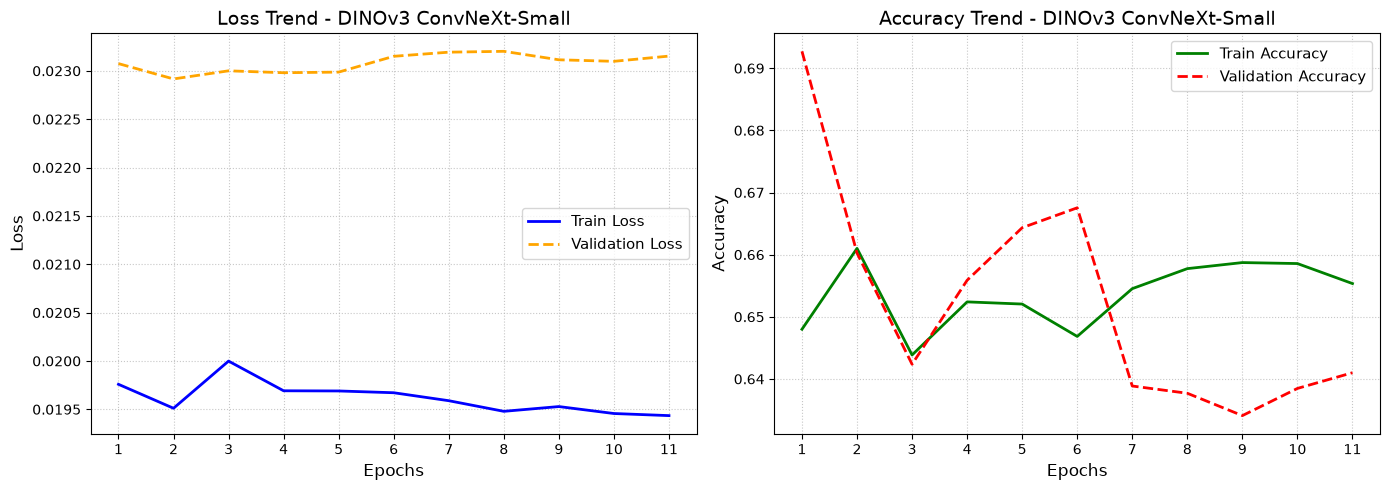

Plot successfully saved as: /home/lucia_pola/internship-deepfake-forensic/deepfake-forensics-pipeline/02_Extended_Framework/deepfake_models_final/retrain_dino/curves/curves_dinov3_convnext-small.png


In [9]:
def plot_learning_curves(csv_path, model_name="Model", curves_path=None):
    """
    Reads the history CSV and saves an image with the Loss and Accuracy curves
    to the specified curves_path.
    """
    if curves_path is None:
        curves_path = os.path.join(MODELS_DIR, 'retrain_dino', 'curves')

    if not os.path.exists(csv_path):
        print(f"Error: The file {csv_path} does not exist.")
        return

    # Load the saved data
    df = pd.read_csv(csv_path)
    epochs = df['epoch']

    plt.figure(figsize=(14, 5))

    # PLOT 1: LOSS
    plt.subplot(1, 2, 1)
    plt.plot(epochs, df['train_loss'], label='Train Loss', color='blue', linewidth=2)
    plt.plot(epochs, df['val_loss'], label='Validation Loss', color='orange', linewidth=2, linestyle='--')
    plt.title(f'Loss Trend - {model_name}', fontsize=14)
    plt.xlabel('Epochs', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.legend(fontsize=11)
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.xticks(epochs)

    # PLOT 2: ACCURACY
    plt.subplot(1, 2, 2)
    plt.plot(epochs, df['train_acc'], label='Train Accuracy', color='green', linewidth=2)
    plt.plot(epochs, df['val_acc'], label='Validation Accuracy', color='red', linewidth=2, linestyle='--')
    plt.title(f'Accuracy Trend - {model_name}', fontsize=14)
    plt.xlabel('Epochs', fontsize=12)
    plt.ylabel('Accuracy', fontsize=12)
    plt.legend(fontsize=11)
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.xticks(epochs)

    plt.tight_layout()

    # Ensure the target directory exists
    os.makedirs(curves_path, exist_ok=True)

    # Generate the file name and final output path
    file_name = f"curves_{model_name.replace(' ', '_').lower()}.png"
    output_path = os.path.join(curves_path, file_name)

    # Save and display the plot
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    plt.show()

    print(f"Plot successfully saved as: {output_path}")

plot_learning_curves(os.path.join(path_intra, 'dino_convnext_small_step2_history.csv'), model_name='DINOv3 ConvNeXt-Small')